In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("/content/monopoly_data_full.csv")

In [3]:
df

,round_code,when,result,multiplier,rolls,chance_multiplier,total_winners,total_payout,video_uid,when_datetime,when_datetime_ist
0,mdHdhY2_FMLA,1788171175,10,10,0,0,286,2503.0,NaN,2026-08-31 10:12:55,2026-08-31 15:42:55+05:30
1,mdHdhY2_FMLU,1788171138,1,1,0,0,0,NaN,NaN,2026-08-31 10:12:18,2026-08-31 15:42:18+05:30
2,mdHdhY2_FML4,1788171100,5,5,0,0,212,1092.0,NaN,2026-08-31 10:11:40,2026-08-31 15:41:40+05:30
3,mdHdhY2_FMKU,1788171064,1,1,0,0,123,385.0,NaN,2026-08-31 10:11:04,2026-08-31 15:41:04+05:30
4,mdHdhY2_FMK4,1788171022,2,2,0,0,220,1001.0,NaN,2026-08-31 10:10:22,2026-08-31 15:40:22+05:30
...,...,...,...,...,...,...,...,...,...,...,...
49995,mdHdhY2_ezUg,1785355079,1,1,0,0,182,275.0,NaN,2026-07-29 19:57:59,2026-07-30 01:27:59+05:30
49996,mdHdhY2_ezXI,1785355036,5,5,0,0,479,1804.0,NaN,2026-07-29 19:57:16,2026-07-30 01:27:16+05:30
49997,mdHdhY2_ezXg,1785354993,2,2,0,0,313,1311.0,NaN,2026-07-29 19:56:33,2026-07-30 01:26:33+05:30
49998,mdHdhY2_ezWU,1785354951,1,1,0,0,201,378.0,NaN,2026-07-29 19:55:51,2026-07-30 01:25:51+05:30


In [4]:
df_copy =df.copy()

In [5]:
df_copy

,round_code,when,result,multiplier,rolls,chance_multiplier,total_winners,total_payout,video_uid,when_datetime,when_datetime_ist
0,mdHdhY2_FMLA,1788171175,10,10,0,0,286,2503.0,NaN,2026-08-31 10:12:55,2026-08-31 15:42:55+05:30
1,mdHdhY2_FMLU,1788171138,1,1,0,0,0,NaN,NaN,2026-08-31 10:12:18,2026-08-31 15:42:18+05:30
2,mdHdhY2_FML4,1788171100,5,5,0,0,212,1092.0,NaN,2026-08-31 10:11:40,2026-08-31 15:41:40+05:30
3,mdHdhY2_FMKU,1788171064,1,1,0,0,123,385.0,NaN,2026-08-31 10:11:04,2026-08-31 15:41:04+05:30
4,mdHdhY2_FMK4,1788171022,2,2,0,0,220,1001.0,NaN,2026-08-31 10:10:22,2026-08-31 15:40:22+05:30
...,...,...,...,...,...,...,...,...,...,...,...
49995,mdHdhY2_ezUg,1785355079,1,1,0,0,182,275.0,NaN,2026-07-29 19:57:59,2026-07-30 01:27:59+05:30
49996,mdHdhY2_ezXI,1785355036,5,5,0,0,479,1804.0,NaN,2026-07-29 19:57:16,2026-07-30 01:27:16+05:30
49997,mdHdhY2_ezXg,1785354993,2,2,0,0,313,1311.0,NaN,2026-07-29 19:56:33,2026-07-30 01:26:33+05:30
49998,mdHdhY2_ezWU,1785354951,1,1,0,0,201,378.0,NaN,2026-07-29 19:55:51,2026-07-30 01:25:51+05:30


##OBJECTIVE

Our project will have two goals


Goal A — Data science

Investigate whether historical Monopoly Live data contains predictive information.

Goal B — Machine learning engineering

Build a complete reproducible pipeline:

CSV

 ↓

Data validation

 ↓

EDA

 ↓

Feature engineering

 ↓

Time-series split

 ↓

Model training

 ↓

Evaluation





#2.EDA

In [6]:
# Convert timestamp
df_copy["when_datetime_ist"] = pd.to_datetime(
    df_copy["when"], unit="s",
    errors= "coerce"
)

# Sort chronologically
df_copy = df_copy.sort_values("when_datetime_ist").reset_index(drop=True)

#
print("Dataset shape:", df_copy.shape)
df_copy.head()

Dataset shape: (50000, 11)


,round_code,when,result,multiplier,rolls,chance_multiplier,total_winners,total_payout,video_uid,when_datetime,when_datetime_ist
0,mdHdhY2_ezW8,1785354909,10,10,0,0,541,5813.0,NaN,2026-07-29 19:55:09,2026-07-29 19:55:09
1,mdHdhY2_ezWU,1785354951,1,1,0,0,201,378.0,NaN,2026-07-29 19:55:51,2026-07-29 19:55:51
2,mdHdhY2_ezXg,1785354993,2,2,0,0,313,1311.0,NaN,2026-07-29 19:56:33,2026-07-29 19:56:33
3,mdHdhY2_ezXI,1785355036,5,5,0,0,479,1804.0,NaN,2026-07-29 19:57:16,2026-07-29 19:57:16
4,mdHdhY2_ezUg,1785355079,1,1,0,0,182,275.0,NaN,2026-07-29 19:57:59,2026-07-29 19:57:59


In [9]:
#Inspection

print("Rows :", df_copy.shape[0])
print("Columns :", df_copy.shape[1])

print("Missing values :", df_copy.isnull().sum())
print("Duplicate rows :", df_copy.duplicated().sum())

Rows : 50000
Columns : 11
Missing values : round_code               0
when                     0
result                   0
multiplier               0
rolls                    0
chance_multiplier        0
total_winners            0
total_payout          1873
video_uid            50000
when_datetime            0
when_datetime_ist        0
dtype: int64
Duplicate rows : 19


In [10]:
#Checking the data range

print("Start date:", df_copy.when_datetime_ist.min())
print("End Date:", df_copy.when_datetime_ist.max())

Start date: 2026-07-29 19:55:09
End Date: 2026-08-31 10:12:55


In [11]:
print(
    "Number of days:",
    df_copy["when_datetime_ist"].dt.date.nunique()
)

Number of days: 34


In [12]:
#Our main target is result

result_counts = df_copy["result"].value_counts().sort_index()
print(result_counts)

result
1     20322
2     13985
5      6565
10     3698
20     2752
40      851
50     1827
Name: count, dtype: int64


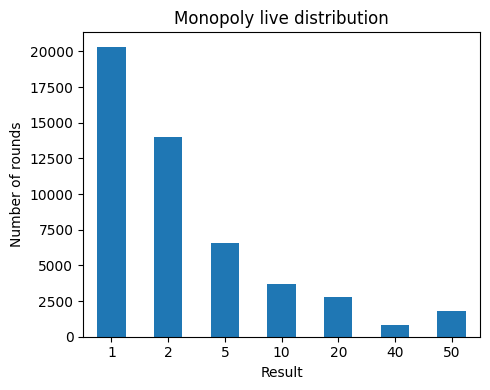

In [20]:
#Visualizing

import matplotlib.pyplot as plt

plt.figure( figsize=(5,4))
result_counts.plot(kind="bar")
plt.title("Monopoly live distribution")
plt.xlabel("Result")
plt.ylabel("Number of rounds")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


The classes are highly imbalanced.

A model that predicts 1 frequently can achieve surprisingly high accuracy.

Therefore, accuracy alone will not be enough.

In [21]:
#Establishing our baseline
baseline_accuracy = df_copy["result"].value_counts(normalize=True).max()
print("Baseline accuracy :", baseline_accuracy)


Baseline accuracy : 0.40644


If we simply predict 1 for every future round, we'd be correct about 40.6% of the time on this historical sample.

This is our baseline to beat.

In [22]:
#examining the multiplier

print(df_copy["multiplier"].describe())

count    50000.000000
mean         4.259600
std         12.132307
min          0.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        628.000000
Name: multiplier, dtype: float64


The maximum of 628 means the distribution is extremely right-skewed.

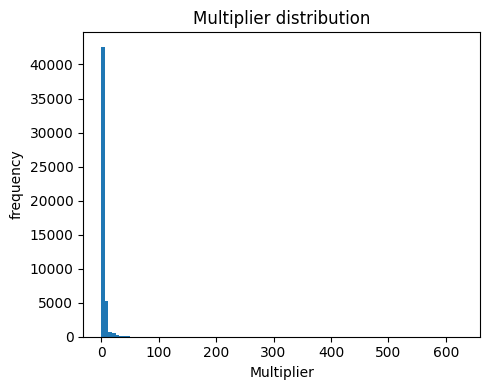

In [24]:
#visualize it

plt.figure(figsize=(5,4))
plt.hist(df_copy["multiplier"],bins=100)

plt.title("Multiplier distribution")
plt.xlabel("Multiplier")
plt.ylabel("frequency")
plt.tight_layout()
plt.show()

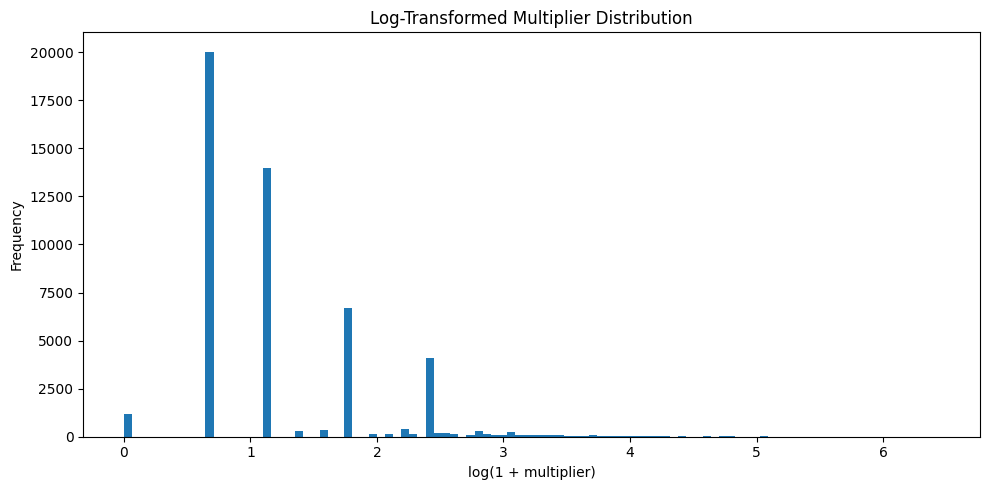

In [25]:
#creating a logscale version of the visualization as it is heavily skewed in the previous multiplier graph
plt.figure(figsize=(10, 5))

plt.hist(
    np.log1p(df_copy["multiplier"]),
    bins=100
)

plt.title("Log-Transformed Multiplier Distribution")
plt.xlabel("log(1 + multiplier)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

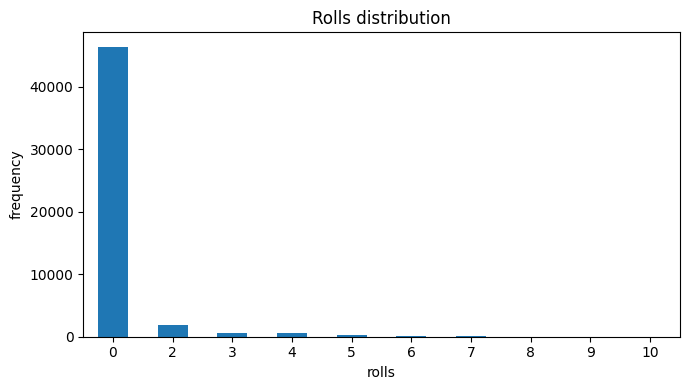

In [28]:
#Analyzing Rolls

roll_counts = df_copy["rolls"].value_counts().sort_index()

plt.figure(figsize=(7,4))
roll_counts.plot(kind= "bar")
plt.title("Rolls distribution")
plt.xlabel("rolls")
plt.ylabel("frequency")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



In [29]:
# Analyzing chance mulitplier

chance_counts = df_copy["chance_multiplier"].value_counts().sort_index()
chance_counts

,count
chance_multiplier,
0,48835
2,320
3,149
4,189
5,160
8,191
10,156


We can see

chance_multiplier = 0

appears in roughly ~97% of the records.

That makes this feature highly imbalanced as well.

In [30]:
#Checking the relationship between multipler and result

print(
    "Result equals multiplier:",
    (df_copy["result"] == df_copy["multiplier"]).mean()
)


Result equals multiplier: 0.8725


we see that they are identical in most of the ways but not always

In [31]:
# let's check for the differences

different = df_copy[
    df_copy["result"] != df_copy["multiplier"]
]

print("Number of different records:", len(different))

print(
    different[
        [
            "result",
            "multiplier",
            "rolls",
            "chance_multiplier"
        ]
    ].head(20)
)


Number of different records: 6375
     result  multiplier  rolls  chance_multiplier
10       20          19      2                  0
49       50           3      0                  0
59       20          15      2                  0
62       20          19      3                  0
63       40          16      4                  0
64       50           2      0                  0
67       20          15      2                  0
85       40          15      4                  0
86       20           7      2                  0
89       20          17      3                  0
97       40          84      7                  0
106      50           0      0                  2
107       1           2      0                  0
114      20          15      3                  0
116      20          31      3                  0
128      40          20      4                  0
129      40         100      5                  0
140      40          42      5                  0
144      20     

In [32]:
#Investigating duplicated round cases

duplicate_rounds = df_copy[
    df_copy["round_code"].duplicated(keep=False)
].sort_values("round_code")

print(
    "Rows with duplicate round codes:",
    len(duplicate_rounds)
)

print(
    "Unique duplicated round codes:",
    duplicate_rounds["round_code"].nunique()
)



Rows with duplicate round codes: 2336
Unique duplicated round codes: 1152


In [33]:
duplicate_rounds[
    [
        "round_code",
        "when_datetime_ist",
        "result",
        "multiplier",
        "rolls",
        "chance_multiplier"
    ]
].head(20)

,round_code,when_datetime_ist,result,multiplier,rolls,chance_multiplier
33463,mdHdhY2_A-1Y,2026-08-20 12:20:50,2,6,0,0
33462,mdHdhY2_A-1Y,2026-08-20 12:20:49,50,0,0,3
33449,mdHdhY2_A-MU,2026-08-20 12:09:13,10,80,0,0
33448,mdHdhY2_A-MU,2026-08-20 12:09:12,50,0,0,8
34346,mdHdhY2_A0VI,2026-08-21 01:31:36,50,8,0,0
34345,mdHdhY2_A0VI,2026-08-21 01:31:35,50,0,0,8
34500,mdHdhY2_A1_g,2026-08-21 03:41:53,1,1,0,0
34499,mdHdhY2_A1_g,2026-08-21 03:41:53,1,1,0,0
34173,mdHdhY2_A2Hg,2026-08-20 23:02:14,50,0,0,10
34174,mdHdhY2_A2Hg,2026-08-20 23:02:15,1,10,0,0


That strongly suggests that round_code isn't simply a unique identifier for every row in this scraped dataset—or the scraper captured multiple events associated with a round.

In [36]:
# Examining Time intervals

df_copy["time_gap_seconds"] = (
    df_copy["when_datetime_ist"].diff().dt.total_seconds()
)

print(
    df_copy["time_gap_seconds"].describe()
)

count    49999.000000
mean        56.326447
std         88.613614
min          0.000000
25%         40.000000
50%         42.000000
75%         45.000000
max      11554.000000
Name: time_gap_seconds, dtype: float64


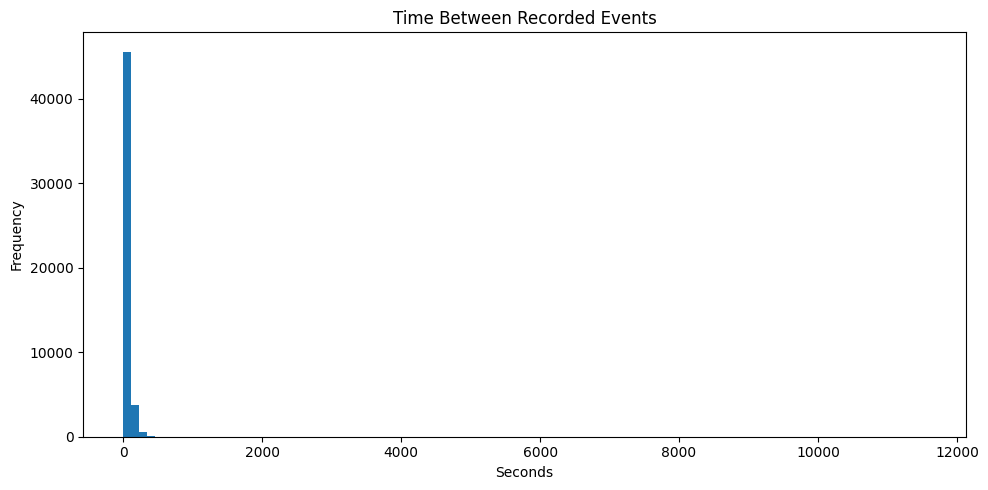

In [38]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_copy["time_gap_seconds"].dropna(),
    bins=100
)

plt.title("Time Between Recorded Events")
plt.xlabel("Seconds")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

We found:

median ~ 42 seconds

but there are also unusually large gaps and some 0-second gaps.

That supports our suspicion that the CSV may contain more than one event/record associated with some rounds.

In [39]:
# Looking at results over time
df_copy["date"] = df_copy["when_datetime_ist"].dt.date

daily_result = pd.crosstab(
    df_copy["date"],
    df_copy["result"],
    normalize="index"
)

print(daily_result.head())

result            1         2         5         10        20        40  \
date                                                                     
2026-07-29  0.450980  0.286275  0.086275  0.066667  0.050980  0.035294   
2026-07-30  0.410472  0.281189  0.124111  0.069813  0.054945  0.021332   
2026-07-31  0.419416  0.269036  0.134518  0.079949  0.048858  0.015863   
2026-08-01  0.419924  0.259773  0.147541  0.069357  0.049811  0.013871   
2026-08-02  0.400389  0.268657  0.138222  0.083063  0.059053  0.012330   

result            50  
date                  
2026-07-29  0.023529  
2026-07-30  0.038138  
2026-07-31  0.032360  
2026-08-01  0.039723  
2026-08-02  0.038287  


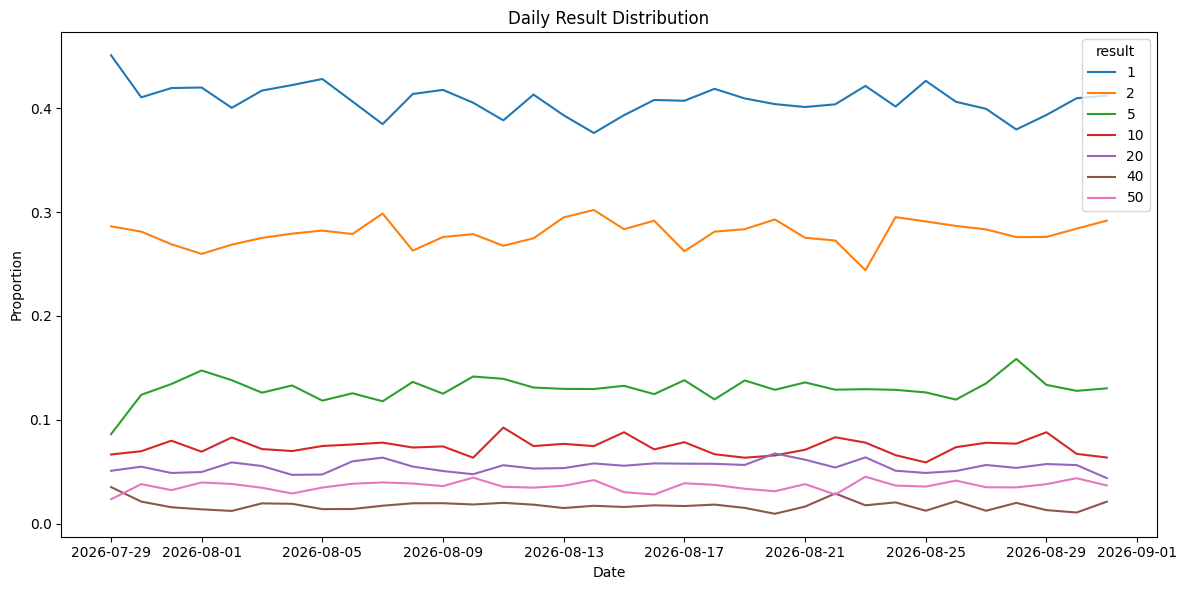

In [41]:
#visualize
daily_result.plot(
    figsize=(12, 6)
)

plt.title("Daily Result Distribution")
plt.xlabel("Date")
plt.ylabel("Proportion")

plt.tight_layout()
plt.show()

In [42]:
#Check time-of-day effects
df_copy["hour"] = df_copy["when_datetime_ist"].dt.hour

hourly_result = pd.crosstab(
    df_copy["hour"],
    df_copy["result"],
    normalize="index"
)

print(
    hourly_result.round(3)
)


result     1      2      5      10     20     40     50
hour                                                   
0       0.409  0.276  0.133  0.074  0.054  0.021  0.033
1       0.408  0.294  0.119  0.077  0.053  0.016  0.033
2       0.401  0.271  0.141  0.071  0.066  0.014  0.036
3       0.411  0.278  0.128  0.090  0.048  0.013  0.032
4       0.402  0.265  0.135  0.082  0.056  0.020  0.039
5       0.394  0.273  0.147  0.070  0.062  0.016  0.038
6       0.426  0.273  0.130  0.062  0.054  0.017  0.038
7       0.415  0.285  0.127  0.078  0.048  0.016  0.032
8       0.410  0.275  0.139  0.068  0.053  0.016  0.040
9       0.404  0.296  0.115  0.073  0.056  0.020  0.036
10      0.419  0.280  0.143  0.063  0.048  0.017  0.030
11      0.398  0.275  0.126  0.086  0.065  0.017  0.033
12      0.408  0.275  0.132  0.076  0.058  0.018  0.034
13      0.415  0.278  0.137  0.068  0.049  0.018  0.034
14      0.412  0.272  0.133  0.079  0.054  0.016  0.036
15      0.409  0.263  0.142  0.076  0.056  0.016

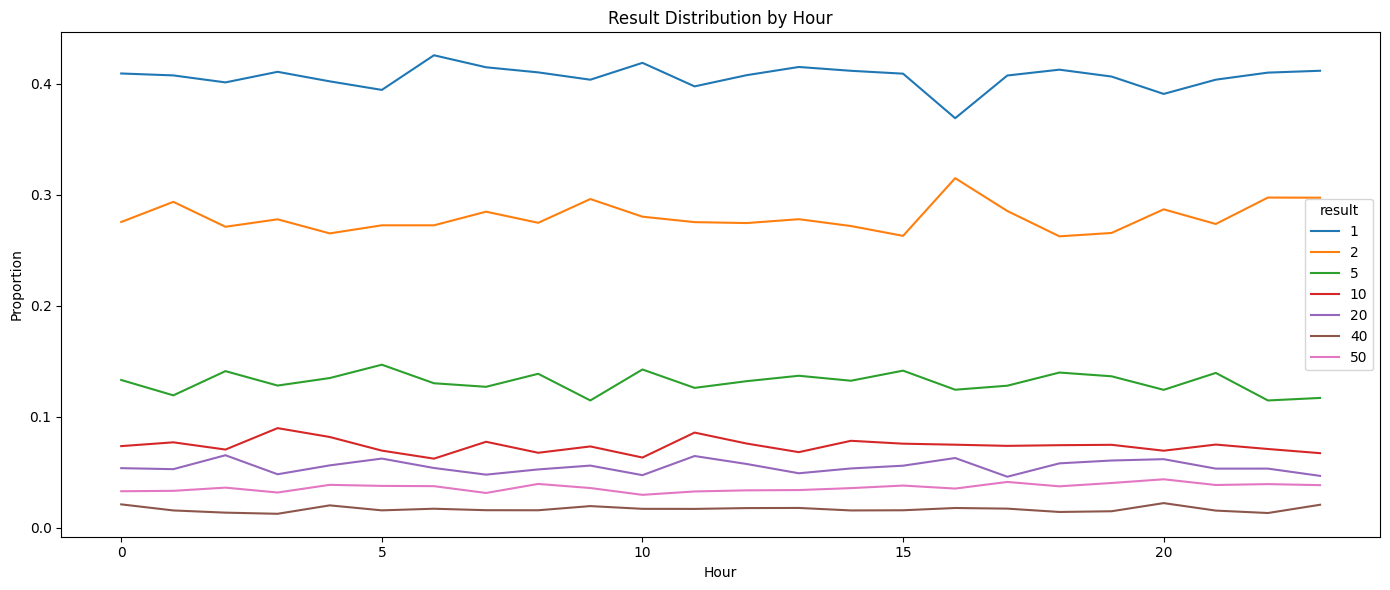

In [43]:
#Visualize
hourly_result.plot(
    figsize=(14, 6)
)

plt.title("Result Distribution by Hour")
plt.xlabel("Hour")
plt.ylabel("Proportion")

plt.tight_layout()
plt.show()


From the actual dataset, the hourly distributions look fairly similar, although there is some variation.

That's already interesting.

It means we shouldn't automatically assume:

"Certain hours produce better results."



#Data Cleaning